In [1]:
import os; os.environ['WORKDIR'] = "/Users/choij/workspace/ChargedHiggsAnalysis"
import sys; sys.path.insert(0, os.environ['WORKDIR'])
import numpy as np
import torch

from libPython.Preprocessor import evt_to_graph
from libPython.MLTools import ParticleNet
from libPython.Management import predict_proba

from libPython.DataFormat import get_muons, get_electrons, get_jets, Particle
from libPython.Selection import pass_baseline, select
from libPython.HistTools import HistogramWriter
from ROOT import TCanvas
from ROOT import TFile
from ROOT import TH1D
from ROOT import TLegend, TLatex

Welcome to JupyROOT 6.26/06


In [2]:
paramDict = {
    "MHc-70_MA-15": {"optim": "AdamW", "initLR": 0.002, "scheduler": "StepLR"},
    "MHc-100_MA-60": {"optim": "Adam", "initLR": 0.01, "scheduler": "StepLR"},
    "MHc-130_MA-90": {"optim": "RMSprop", "initLR": 0.0002, "scheduler": "ExponentialLR"},
    "MHc-160_MA-155": {"optim": "AdamW", "initLR": 2e-05, "scheduler": "ExponentialLR"}
}

In [3]:
def getScore(model, objects):
    model.eval()
    node_list = []
    for obj in objects:
        node_list.append([obj.Pt(),
                          obj.Eta(),
                          obj.Phi(),
                          obj.M(),
                          obj.Charge(),
                          obj.IsMuon(),
                          obj.IsElectron(),
                          obj.IsJet(),
                          obj.BtagScore()])
    data = evt_to_graph(node_list, y=None, k=4)
    return predict_proba(model, data.x, data.edge_index)

In [4]:
def makeACand(muons, mA):
    ACand = Particle(0., 0., 0., 0.)
    xACand = Particle(0., 0., 0., 0.)
    # make pairs
    if abs(muons[0].Charge() + muons[1].Charge()) == 2:
        pair1 = muons[0] + muons[2]
        pair2 = muons[1] + muons[2]
    elif abs(muons[0].Charge() + muons[2].Charge()) == 2:
        pair1 = muons[0] + muons[1]
        pair2 = muons[1] + muons[2]
    else:   # 1 == 2
        pair1 = muons[0] + muons[1]
        pair2 = muons[0] + muons[2]
        
    if abs(pair1.M() - mA) < abs(pair2.M() - mA):
        ACand, xACand = pair1, pair2
    else:
        ACand, xACand = pair2, pair1
    return (ACand, xACand)

In [5]:
MASSPOINT = "MHc-130_MA-90"
BACKGROUND = "ttX"
ERA = "2018"
MA = MASSPOINT.split("_")[1]
MA = int(MA.split("-")[1])

# load model
optim = paramDict[MASSPOINT]["optim"]
initLR = paramDict[MASSPOINT]["initLR"]
scheduler = paramDict[MASSPOINT]["scheduler"]
model_path = f"{os.environ['WORKDIR']}/models/full/{MASSPOINT}_vs_{BACKGROUND}/ParticleNet_{optim}_initLR-{str(initLR).replace('.', 'p')}_{scheduler}.pt"
model = ParticleNet(num_features=9, num_classes=2, hidden_channels=128)
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))

# histogram writer
writer = HistogramWriter(outfile=f"{os.environ['WORKDIR']}/triLepRegion/ROOT/corrStudy/targetTTX.root")

In [6]:
# signal
arrScore = []
arrACand = []

f = TFile.Open(f"{os.environ['WORKDIR']}/SelectorOutput/{ERA}/Skim3Mu__/Selector_TTToHcToWAToMuMu_{MASSPOINT}.root")
for evt in f.Events:
    muons = get_muons(evt)
    electrons = get_electrons(evt)
    jets, bjets = get_jets(evt)
    METv = Particle(evt.METvPt, 0., evt.METvPhi, 0.)
    weight = evt.GenWeight * evt.TrigLumi
        
    #if not pass_baseline("3Mu", evt, muons, electrons, jets ,bjets, "loose"):
    #    continue
    region = select("3Mu", evt, muons, electrons, jets, bjets, "tight")
    if region != "SignalRegion":
        continue
    
    objects = muons+electrons+jets
    objects.append(METv)
    score = getScore(model, objects)
    ACand, xACand = makeACand(muons, MA)
    
    arrScore.append(score)
    arrACand.append(abs(ACand.M() - MA))
    
    writer.fill_hist("signal/score", score, weight, 100, 0., 1.)
    writer.fill_object("signal/ACand", ACand, weight)
    writer.fill_object("signal/xACand", xACand, weight)
    
    if score > 0.8:
        writer.fill_object("signal/score_0p8to1p0/ACand", ACand, weight)
    elif score > 0.6:
        writer.fill_object("signal/score_0p6to0p8/ACand", ACand, weight)
    elif score > 0.4:
        writer.fill_object("signal/score_0p4to0p6/ACand", ACand, weight)
    elif score > 0.2:
        writer.fill_object("signal/score_0p2to0p4/ACand", ACand, weight)
    else:
        writer.fill_object("signal/score_0to0p2/ACand", ACand, weight)
f.Close()

arrScore = np.array(arrScore)
arrACand = np.array(arrACand)

print(np.corrcoef(arrScore, arrACand))

[[ 1.         -0.06130706]
 [-0.06130706  1.        ]]


In [9]:
# background
arrScore = []
arrACand = []

f = TFile.Open(f"{os.environ['WORKDIR']}/SelectorOutput/{ERA}/Skim3Mu__/Selector_ttZToLLNuNu_copy.root")
for evt in f.Events:
    muons = get_muons(evt)
    electrons = get_electrons(evt)
    jets, bjets = get_jets(evt)
    METv = Particle(evt.METvPt, 0., evt.METvPhi, 0.)
    weight = evt.GenWeight * evt.TrigLumi * 10
    
    #if not pass_baseline("3Mu", evt, muons, electrons, jets ,bjets, "loose"):
    #    continue
    region = select("3Mu", evt, muons, electrons, jets, bjets, "tight")
    if region != "SignalRegion":
        continue
    
    objects = muons+electrons+jets
    objects.append(METv)
    score = getScore(model, objects)
    ACand, xACand = makeACand(muons, MA)
    
    arrScore.append(score)
    arrACand.append(abs(ACand.M() - MA))
    
    writer.fill_hist("background/score", score, weight, 100, 0., 1.)
    writer.fill_object("background/ACand", ACand, weight)
    writer.fill_object("background/xACand", xACand, weight)
    
    if score > 0.8:
        writer.fill_object("background/score_0p8to1p0/ACand", ACand, weight)
    elif score > 0.6:
        writer.fill_object("background/score_0p6to0p8/ACand", ACand, weight)
    elif score > 0.4:
        writer.fill_object("background/score_0p4to0p6/ACand", ACand, weight)
    elif score > 0.2:
        writer.fill_object("background/score_0p2to0p4/ACand", ACand, weight)
    else:
        writer.fill_object("background/score_0to0p2/ACand", ACand, weight)
f.Close()
writer.close()

arrScore = np.array(arrScore)
arrACand = np.array(arrACand)

print(np.corrcoef(arrScore, arrACand))

Saving histograms in /Users/choij/workspace/ChargedHiggsAnalysis/triLepRegion/ROOT/corrStudy/targetTTX.root...
[[ 1.         -0.03599646]
 [-0.03599646  1.        ]]


Warning in <TCanvas::Constructor>: Deleting canvas with same name: mA


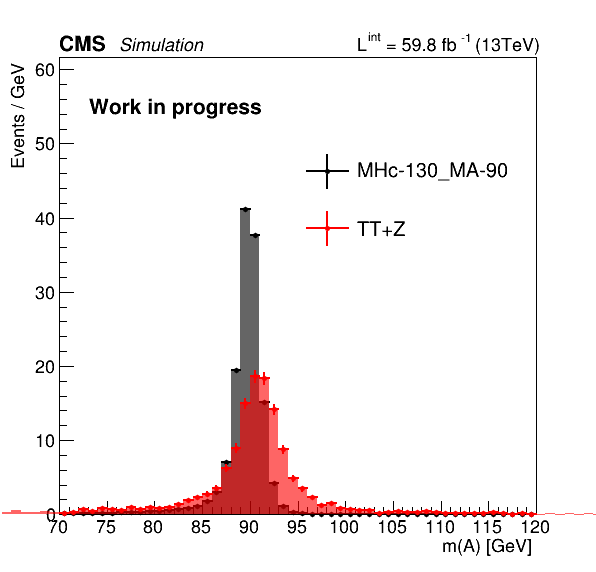

In [12]:
from ROOT import TCanvas, TFile

f = TFile.Open("../ROOT/corrStudy/targetTTX.root")
h_sig = f.Get("signal/ACand/mass"); h_sig.SetDirectory(0)
h_bkg = f.Get("background/ACand/mass"); h_bkg.SetDirectory(0)

h_sig.SetStats(0)
h_sig.SetMarkerStyle(8); h_sig.SetMarkerSize(0.7); h_sig.SetMarkerColor(1)
h_sig.SetFillColorAlpha(1, 0.6)
h_bkg.SetStats(0)
h_bkg.SetMarkerStyle(8); h_bkg.SetMarkerSize(0.7); h_bkg.SetMarkerColor(2)
h_bkg.SetFillColorAlpha(2, 0.6)

h_sig.GetXaxis().SetTitle("m(A) [GeV]")
h_sig.GetXaxis().SetRangeUser(70., 120.)
h_sig.GetYaxis().SetTitle("Events / GeV")
h_sig.GetYaxis().SetRangeUser(0., h_sig.GetMaximum()*1.5)

h_sig.SetLineColor(1); h_sig.SetLineWidth(2)
h_bkg.SetLineColor(2); h_bkg.SetLineWidth(2)

legend = TLegend(0.5, 0.55, 0.90, 0.75)
legend.SetFillStyle(0)
legend.SetBorderSize(0)
legend.AddEntry(h_sig, "MHc-130_MA-90", "lep")
legend.AddEntry(h_bkg, "TT+Z", "lep")

cms = TLatex()
cms.SetTextSize(0.04)
cms.SetTextFont(61)
simulation = TLatex()
simulation.SetTextSize(0.035)
simulation.SetTextFont(52)
lumi = TLatex()
lumi.SetTextSize(0.035)
lumi.SetTextFont(42)
work = TLatex()
work.SetTextSize(0.04)
work.SetTextFont(61)


c = TCanvas("mA", "", 600, 600)
c.cd()
h_sig.Draw("bar")
h_bkg.Draw("same&bar")
legend.Draw()
cms.DrawLatexNDC(0.1, 0.91, "CMS")
simulation.DrawLatexNDC(0.2, 0.91, "Simulation")
lumi.DrawLatexNDC(0.6, 0.91, "L^{int} = 59.8 fb^{-1} (13TeV)")
work.DrawLatexNDC(0.15, 0.8, "Work in progress")
c.Draw()
f.Close()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: score


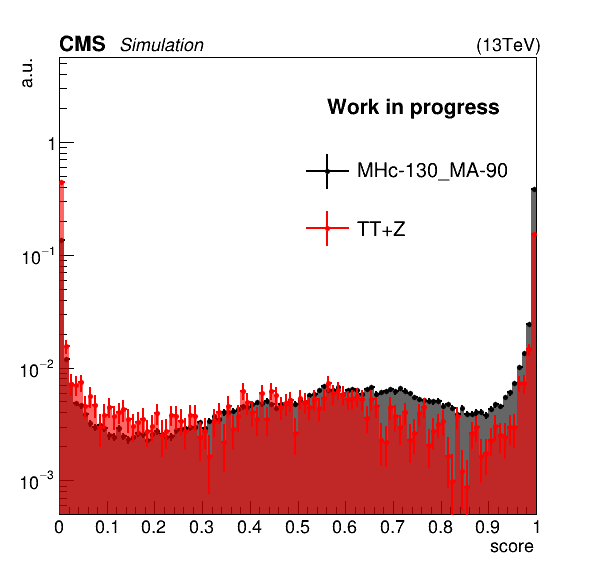

In [17]:
f = TFile.Open("../ROOT/corrStudy/targetTTX.root")
h_sig = f.Get("signal/score"); h_sig.SetDirectory(0); h_sig.SetStats(0)
h_bkg = f.Get("background/score"); h_bkg.SetDirectory(0); h_bkg.SetStats(0)
#h_sig.Rebin(5)
#h_bkg.Rebin(5)

h_sig.Scale(1./h_sig.Integral())
h_bkg.Scale(1./h_bkg.Integral())

h_sig.GetXaxis().SetTitle("score")
h_sig.GetYaxis().SetTitle("a.u.")
h_sig.GetYaxis().SetTitleOffset(1.)
h_sig.GetYaxis().SetRangeUser(5e-4, h_sig.GetMaximum()*15)

h_sig.SetMarkerStyle(8); h_sig.SetMarkerSize(0.7); h_sig.SetMarkerColor(1)
h_sig.SetLineColor(1); h_sig.SetLineWidth(2)
h_sig.SetFillColorAlpha(1, 0.6)
h_bkg.SetMarkerStyle(8); h_bkg.SetMarkerSize(0.7); h_bkg.SetMarkerColor(2)
h_bkg.SetLineColor(2); h_bkg.SetLineWidth(2)
h_bkg.SetFillColorAlpha(2, 0.6)


legend = TLegend(0.5, 0.55, 0.90, 0.75)
legend.SetFillStyle(0)
legend.SetBorderSize(0)
legend.AddEntry(h_sig, "MHc-130_MA-90", "lep")
legend.AddEntry(h_bkg, "TT+Z", "lep")

cms = TLatex()
cms.SetTextSize(0.04)
cms.SetTextFont(61)
simulation = TLatex()
simulation.SetTextSize(0.035)
simulation.SetTextFont(52)
lumi = TLatex()
lumi.SetTextSize(0.035)
lumi.SetTextFont(42)
work = TLatex()
work.SetTextSize(0.04)
work.SetTextFont(61)

c = TCanvas("score", "", 600, 600)
c.SetLogy()
c.cd()
h_sig.Draw("bar")
h_bkg.Draw("same&bar")
legend.Draw()
cms.DrawLatexNDC(0.1, 0.91, "CMS")
simulation.DrawLatexNDC(0.2, 0.91, "Simulation")
lumi.DrawLatexNDC(0.8, 0.91, "(13TeV)")
work.DrawLatexNDC(0.55, 0.8, "Work in progress")
c.Draw()
f.Close()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: signal


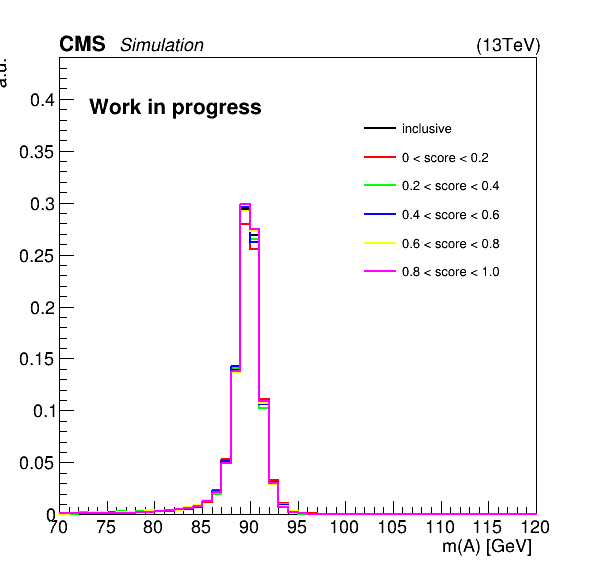

In [19]:
f = TFile.Open("../ROOT/corrStudy/targetTTX.root")
h_sig = f.Get("signal/ACand/mass"); h_sig.SetDirectory(0); h_sig.SetStats(0)
h_0p2 = f.Get("signal/score_0to0p2/ACand/mass"); h_0p2.SetDirectory(0)
h_0p4 = f.Get("signal/score_0p2to0p4/ACand/mass"); h_0p4.SetDirectory(0)
h_0p6 = f.Get("signal/score_0p4to0p6/ACand/mass"); h_0p6.SetDirectory(0)
h_0p8 = f.Get("signal/score_0p6to0p8/ACand/mass"); h_0p8.SetDirectory(0)
h_1p0 = f.Get("signal/score_0p8to1p0/ACand/mass"); h_1p0.SetDirectory(0)

h_sig.Scale(1./h_sig.Integral())
h_0p2.Scale(1./h_0p2.Integral())
h_0p4.Scale(1./h_0p4.Integral())
h_0p6.Scale(1./h_0p6.Integral())
h_0p8.Scale(1./h_0p8.Integral())
h_1p0.Scale(1./h_1p0.Integral())

h_sig.GetXaxis().SetTitle("m(A) [GeV]")
h_sig.GetXaxis().SetRangeUser(70., 120.)
h_sig.GetYaxis().SetTitle("a.u.")
h_sig.GetYaxis().SetRangeUser(0., h_sig.GetMaximum()*1.5)
h_sig.SetLineColor(1); h_sig.SetLineWidth(2)
h_0p2.SetLineColor(2); h_0p2.SetLineWidth(2)
h_0p4.SetLineColor(3); h_0p4.SetLineWidth(2)
h_0p6.SetLineColor(4); h_0p6.SetLineWidth(2)
h_0p8.SetLineColor(5); h_0p8.SetLineWidth(2)
h_1p0.SetLineColor(6); h_1p0.SetLineWidth(2)

legend = TLegend(0.6, 0.5, 0.90, 0.8)
legend.SetFillStyle(0)
legend.SetBorderSize(0)
legend.AddEntry(h_sig, "inclusive", "l")
legend.AddEntry(h_0p2, "0 < score < 0.2", "l")
legend.AddEntry(h_0p4, "0.2 < score < 0.4", "l")
legend.AddEntry(h_0p6, "0.4 < score < 0.6", "l")
legend.AddEntry(h_0p8, "0.6 < score < 0.8", "l")
legend.AddEntry(h_1p0, "0.8 < score < 1.0", "l")

cms = TLatex()
cms.SetTextSize(0.04)
cms.SetTextFont(61)
simulation = TLatex()
simulation.SetTextSize(0.035)
simulation.SetTextFont(52)
lumi = TLatex()
lumi.SetTextSize(0.035)
lumi.SetTextFont(42)
work = TLatex()
work.SetTextSize(0.04)
work.SetTextFont(61)

c = TCanvas("signal", "", 600, 600)
c.cd()
h_sig.Draw("hist")
h_0p2.Draw("hist&same")
h_0p4.Draw("hist&same")
h_0p6.Draw("hist&same")
h_0p8.Draw("hist&same")
h_1p0.Draw("hist&same")
legend.Draw()
cms.DrawLatexNDC(0.1, 0.91, "CMS")
simulation.DrawLatexNDC(0.2, 0.91, "Simulation")
lumi.DrawLatexNDC(0.8, 0.91, "(13TeV)")
work.DrawLatexNDC(0.15, 0.8, "Work in progress")
c.Draw()
f.Close()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: bkg


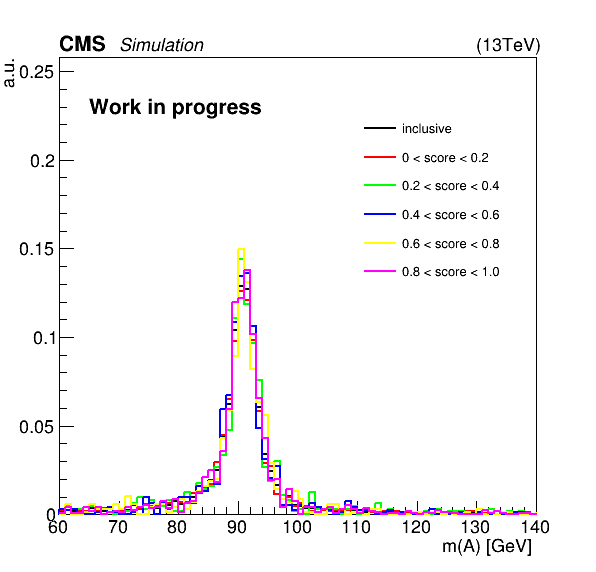

In [23]:
f = TFile.Open("../ROOT/corrStudy/targetTTX.root")
h_bkg = f.Get("background/ACand/mass"); h_bkg.SetDirectory(0); h_bkg.SetStats(0)
h_0p2 = f.Get("background/score_0to0p2/ACand/mass"); h_0p2.SetDirectory(0)
h_0p4 = f.Get("background/score_0p2to0p4/ACand/mass"); h_0p4.SetDirectory(0)
h_0p6 = f.Get("background/score_0p4to0p6/ACand/mass"); h_0p6.SetDirectory(0)
h_0p8 = f.Get("background/score_0p6to0p8/ACand/mass"); h_0p8.SetDirectory(0)
h_1p0 = f.Get("background/score_0p8to1p0/ACand/mass"); h_1p0.SetDirectory(0)
#h_bkg.Rebin(5)
#h_0p2.Rebin(5)
#h_0p4.Rebin(5)
#h_0p6.Rebin(5)
#h_0p8.Rebin(5)
#h_1p0.Rebin(5)

h_bkg.Scale(1./h_bkg.Integral())
h_0p2.Scale(1./h_0p2.Integral())
h_0p4.Scale(1./h_0p4.Integral())
h_0p6.Scale(1./h_0p6.Integral())
h_0p8.Scale(1./h_0p8.Integral())
h_1p0.Scale(1./h_1p0.Integral())

h_bkg.GetXaxis().SetTitle("m(A) [GeV]")
h_bkg.GetXaxis().SetRangeUser(60., 140.)
h_bkg.GetYaxis().SetTitle("a.u.")
h_bkg.GetYaxis().SetTitleOffset(1.5)
h_bkg.GetYaxis().SetRangeUser(0., h_bkg.GetMaximum()*2)
h_bkg.SetLineColor(1); h_bkg.SetLineWidth(2)
h_0p2.SetLineColor(2); h_0p2.SetLineWidth(2)
h_0p4.SetLineColor(3); h_0p4.SetLineWidth(2)
h_0p6.SetLineColor(4); h_0p6.SetLineWidth(2)
h_0p8.SetLineColor(5); h_0p8.SetLineWidth(2)
h_1p0.SetLineColor(6); h_1p0.SetLineWidth(2)

legend = TLegend(0.6, 0.5, 0.90, 0.8)
legend.SetFillStyle(0)
legend.SetBorderSize(0)
legend.AddEntry(h_bkg, "inclusive", "l")
legend.AddEntry(h_0p2, "0 < score < 0.2", "l")
legend.AddEntry(h_0p4, "0.2 < score < 0.4", "l")
legend.AddEntry(h_0p6, "0.4 < score < 0.6", "l")
legend.AddEntry(h_0p8, "0.6 < score < 0.8", "l")
legend.AddEntry(h_1p0, "0.8 < score < 1.0", "l")

cms = TLatex()
cms.SetTextSize(0.04)
cms.SetTextFont(61)
simulation = TLatex()
simulation.SetTextSize(0.035)
simulation.SetTextFont(52)
lumi = TLatex()
lumi.SetTextSize(0.035)
lumi.SetTextFont(42)
work = TLatex()
work.SetTextSize(0.04)
work.SetTextFont(61)

c = TCanvas("bkg", "", 600, 600)
c.cd()
h_bkg.Draw("hist")
h_0p2.Draw("hist&same")
h_0p4.Draw("hist&same")
h_0p6.Draw("hist&same")
h_0p8.Draw("hist&same")
h_1p0.Draw("hist&same")
legend.Draw()
cms.DrawLatexNDC(0.1, 0.91, "CMS")
simulation.DrawLatexNDC(0.2, 0.91, "Simulation")
lumi.DrawLatexNDC(0.8, 0.91, "(13TeV)")
work.DrawLatexNDC(0.15, 0.8, "Work in progress")
c.Draw()
f.Close()